# Angles
General def through dot product
$$A\cdot B= |A||B|\cos\theta$$
$$\cos \theta= \frac{A\cdot B} {|A||B|}$$
and its easy on grids cuz the dot product in cartestian coordinates is simply
$$A_xB_x+A_y+B_y$$
So
$$\cos \theta= \frac {A_xB_x+A_yB_y}{ \sqrt{A_x^2+A_y^2} \sqrt{B_x^2+B_y^2}} $$

In [1]:
from AIce.functions import torchRMSE,trainloader,testloader,redim,getRMSE
from torch import optim
from AIce.models import NNforAngles
import numpy as np
import torch
import matplotlib.pyplot as plt

from time import strftime

# [['u_ERA5','v_ERA5','h_piomas','sic_CDR','x_EASE','y_EASE','bath','sin','cos', 'windnorm'],
#             ['u_ERA5','v_ERA5','h_piomas','sic_CDR','x_EASE','y_EASE','bath','sin','cos'],
#             ['u_ERA5','v_ERA5','h_piomas','sic_CDR','x_EASE','y_EASE','bath'],
#             ['u_ERA5','v_ERA5','h_piomas','sic_CDR','x_EASE','y_EASE'],
#             ['u_ERA5','v_ERA5','h_piomas','sic_CDR'],
#             ['u_ERA5','v_ERA5','h_piomas','sic_CDR', 'windnorm'],
#             ['u_ERA5','v_ERA5','h_piomas'],
#             ['u_ERA5','v_ERA5']]

In [ ]:
# TRAINING LOOP FOR THE ONE TIME RUN FOR EXAMPLE
#  device='cuda'

# inputlist=['u_ERA5','v_ERA5','h_piomas','sic_CDR','x_EASE','y_EASE','bath','sin','cos', 'windnorm']
# lr =1e-3
# n_epoch=20
# data,_,dataloader,means,stds,maxes,labels=trainloader('../data/DRIFT_DATA_TRAIN.csv',256,inputlist,target='angle')
# data=data.loc[data['costheta'==0]]

# mlp256=NNforAngles(len(labels[1])).to(device)
# print('Total Epoch: ', n_epoch)
# print('Learning Rate: ', lr)
# print(labels)

# rlosses={}
# losses=[]
# rloss=0
# rcount=0

# optimizer = optim.Adam(mlp256.parameters(),lr=lr) # optimizers

# for epoch in range(n_epoch):
#     print('Starting Epoch ',epoch)
#     curpercent=0
#     rl=[]
#     for i,data in enumerate(dataloader):

#         # get the inputs and the target
#         truth,inputs= data[0].to(device),data[1].to(device)

#         # zero the gradients,
#         optimizer.zero_grad()

#         # Forward,
#         out=mlp256(inputs)


#         loss = torchRMSE(target=truth, outputs=out)
#         # Backward
#         loss.backward()
#         losses.append(loss.item())
#         # Optimize

#         optimizer.step()

#         rloss+= loss.item()
#         rcount +=1
#         #print where we at plus the loss
#         percent= round(i/len(dataloader)*100)
#         if percent != curpercent:
#         #    print(percent, 'loss: ', rloss/rcount)
#             curpercent=percent
#             rl.append(rloss/rcount)
#             rloss=0
#             rcount=0
#     rlosses[epoch]=rl
#     print('Epoch avg loss: ', np.mean(rl))

# saving_name=f'angle_without_stoppage_{len(labels[1])}inputs_{n_epoch}E_{lr}lr_{strftime("%d-%Hh_%Mm_%Ss")}'

# torch.save(mlp256.state_dict(), f'.//weights//{saving_name}.pt')

# with open(f'.//weights//{saving_name}.txt','w') as f:
#     f.write(f'Model: NNforAngle (on gpu)\n')
#     f.write(f'Weights: {saving_name}.pt\n')
#     f.write(f'Associated inputs: {inputlist}')

# fig,ax =plt.subplots()
# epochavg=[]

# for i in (rlosses):
#     x=np.arange(i*len(rlosses[0]),len(rlosses[0])+i*len(rlosses[0]))
#     ax.plot(x,rlosses[i])#,label=f'Epoch {i+1}, lr={lr[i]:.1e}')
#     avg=np.mean(rlosses[i])
#     epochavg.append(avg)
# xx=[i*len(rlosses[0]) for i in rlosses]
# ax.plot(xx,epochavg,'.-k')
# plt.savefig(f'.//outputs//loss_for_{saving_name}.png')
# plt.close('all')


allright angles
Sin and Cos added
Bathymetry (bath) normalized by maximum
x/y (x_EASE, y_EASE) normalized by maximum
Windnorm normalized by z-score
Wind components (u/v_ERA5) normalized by z-score
           angle
0       0.669591
1       0.997651
2       2.719585
3       0.079998
4       2.405274
...          ...
339151  0.156929
339152  0.134888
339153  0.547946
339154  1.444349
339155  0.273171

[339156 rows x 1 columns]


allright angles
Sin and Cos added
Bathymetry (bath) normalized by maximum
x/y (x_EASE, y_EASE) normalized by maximum
Windnorm normalized by z-score
Wind components (u/v_ERA5) normalized by z-score
             angle
0        38.364730
1       -57.161208
2      -155.820729
3        -4.583557
4       137.812038
...            ...
339151   -8.991385
339152    7.728490
339153   31.394994
339154   82.755074
339155   15.651530

[339156 rows x 1 columns]
3.141592653589793


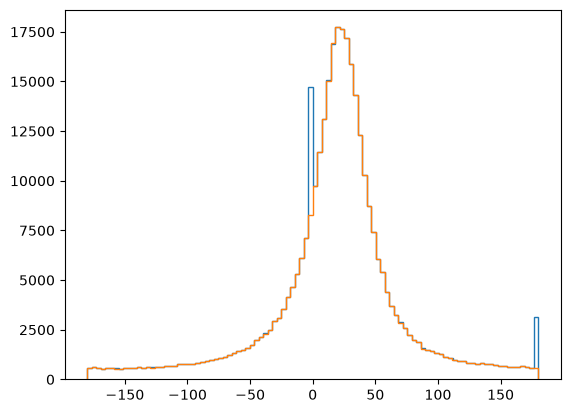

In [18]:
import matplotlib.pyplot as plt
inputlist=['u_ERA5','v_ERA5','h_piomas','sic_CDR','x_EASE','y_EASE','bath','sin','cos', 'windnorm']
data,_,_,means,stds,maxes,_=trainloader('../data/DRIFT_DATA_TRAIN.csv',256,inputlist,target='angle')
data=redim(data,
           means=means,
           stds=stds,
           maxes=maxes)

# plt.hist(data['cos'],100)
plt.show()
plt.hist((data['angle']),100, histtype='step')
plt.hist((data['angle'].loc[data['u_buoy']!=0]), 100, histtype='step')
print(np.arccos(-1))

In [3]:
inputlist=['u_ERA5','v_ERA5','h_piomas','sic_CDR','x_EASE','y_EASE','bath','sin','cos', 'windnorm']
testdata,_,_,means,stds,maxes,_=testloader('../data/DRIFT_DATA_TEST.csv',inputlist
                                    ,'angle',trainingset_loaded=False, training_file='../data/DRIFT_DATA_TRAIN.csv')# Get the means,stds,maxes using the longest list possible
anglemodel= NNforAngles(len(inputlist))
anglemodel.load_state_dict(torch.load('./weights/angle_without_stoppage_19inputs_20E_0.001lr_15-14h_52m_39s.pt', weights_only= True))
anglemodel.eval()

out=anglemodel(torch.tensor(testdata.drop(['angle'],axis=1).values, dtype= torch.float32))
testdata=redim(testdata,
               means=means,
               stds=stds,
               maxes=maxes)

Bath size is the full test set
allright angles
Sin and Cos added
Bathymetry (bath) normalized by maximum
x/y (x_EASE, y_EASE) normalized by maximum
Windnorm normalized by z-score
Wind components (u/v_ERA5) normalized by z-score
Wind components (u/v_ERA5) normalized by z-score


RuntimeError: Error(s) in loading state_dict for NNforAngles:
	size mismatch for fc1.weight: copying a param with shape torch.Size([256, 19]) from checkpoint, the shape in current model is torch.Size([256, 10]).